# Crossnobis validation

All synthetic, ~20 s. Every section ends in an `assert` — rerun after touching
`_crossnobis_loo`, `compute_noise_sd` or `within_run_folds`.

**The idea.** Measuring the distance between two condition means is broken because noise
inflates it: identical conditions still come out apart, and *more* apart the noisier the
subject. Crossnobis instead computes the `(A−B)` difference in two independent halves and
takes their **dot product**. Independent noise vectors point in unrelated directions, so
with no true difference this averages to **0** — negative values are expected, not a bug.
The *-nobis* part is just dividing each voxel by its own noise level first.

**Why not the library.** `rsatoolbox.calc_rdm(method='crossnobis')` builds a dense
`n_voxels × n_voxels` identity to say "weight voxels equally" — 34 GB at whole-brain scale.
`run_rsa_roi.py` computes the same thing without it; §1 justifies that.

| § | Check | Catches |
|---|---|---|
| 1 | Agreement with rsatoolbox, unbalanced folds | Drift from reference semantics |
| 2 | **Unbiasedness under the null** | Bias — the load-bearing one |
| 2b | Invariance to noise level | Distances that track data quality |
| 3 | Recovery of a known distance | Scale errors |
| 4 | Within-run fold balance | A split starving a condition |
| 5 | Noise-SD recovery | Normalisation eating signal |

§2 is why `rsa_roi_results.ipynb` can t-test β against 0 instead of building permutation
nulls per subject per ROI.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd() if Path.cwd().name == "multivariate" else Path.cwd() / "multivariate"))
from run_rsa_roi import _crossnobis_loo, within_run_folds, compute_noise_sd

N_COND = 8
STIM = np.array([f"s{i}" for i in range(N_COND)])
IU = np.triu_indices(N_COND, 1)
rng = np.random.default_rng(0)

try:
    import rsatoolbox
    HAVE_RSATOOLBOX = True
    print("rsatoolbox available — §1 will run")
except ImportError:
    HAVE_RSATOOLBOX = False
    print("rsatoolbox NOT installed — §1 will be skipped.\n"
          "  Install with: pip install rsatoolbox==0.2.0\n"
          "  (0.3.2 needs scikit-learn >= 1.6; this env pins 1.4)")

rsatoolbox available — §1 will run


## 1. Does the local version match rsatoolbox?

Uses **unbalanced** folds (11–23 repeats, as in the real runs). That matters: averaging
per-run then across runs — rather than pooling all training observations — agrees on
balanced data and silently diverges on unbalanced data, which is our case.

max |deviation| over 3 datasets : 1.11e-16   (floating-point identical)


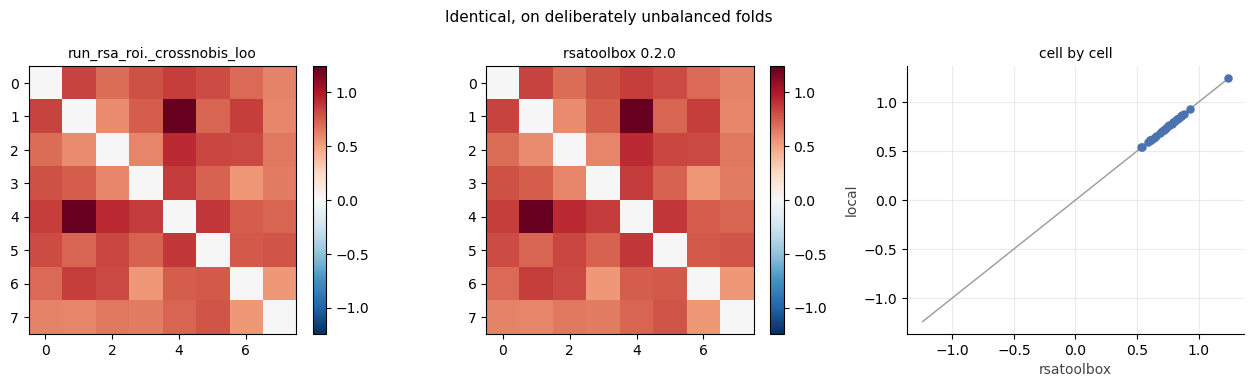

In [2]:
def make_unbalanced(rng, n_vox=50, n_folds=3, lo=11, hi=24, effect=0.6):
    """Synthetic data with 11-23 repeats per condition per fold, as in the real runs."""
    cond, fold = [], []
    for f in range(n_folds):
        for c in range(N_COND):
            k = int(rng.integers(lo, hi))
            cond += [c] * k
            fold += [f] * k
    cond, fold = np.array(cond), np.array(fold)
    true = rng.normal(size=(N_COND, n_vox)) * effect
    return true[cond] + rng.normal(size=(len(cond), n_vox)), cond, fold


def rsatoolbox_rdm(patterns, cond_idx, fold_idx):
    from rsatoolbox.data import Dataset
    from rsatoolbox.rdm import calc_rdm
    ds = Dataset(measurements=patterns,
                 obs_descriptors={"stim": STIM[cond_idx], "fold": fold_idx.astype(str)})
    r = calc_rdm(ds, method="crossnobis", descriptor="stim", cv_descriptor="fold")
    m = r.get_matrices()[0]
    order = np.argsort(np.asarray(r.pattern_descriptors["stim"]))
    return m[np.ix_(order, order)]


if not HAVE_RSATOOLBOX:
    print("SKIPPED — rsatoolbox not installed")
else:
    worst, pairs = 0.0, []
    for _ in range(3):
        pat, cond, fold = make_unbalanced(rng)
        ours = _crossnobis_loo(pat, cond, fold, N_COND)
        ref = rsatoolbox_rdm(pat, cond, fold)
        worst = max(worst, float(np.abs(ours - ref).max()))
        pairs.append((ours, ref))
        assert np.allclose(ours, ref, rtol=1e-6, atol=1e-12)
    print(f"max |deviation| over 3 datasets : {worst:.2e}   (floating-point identical)")

    ours, ref = pairs[0]
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.9))
    lim = np.abs(ours[IU]).max()
    for ax, (m, t) in zip(axes[:2], [(ours, "run_rsa_roi._crossnobis_loo"),
                                     (ref, "rsatoolbox 0.2.0")]):
        im = ax.imshow(m, cmap="RdBu_r", vmin=-lim, vmax=lim)   # signed -> diverging
        ax.set_title(t, fontsize=10)
        fig.colorbar(im, ax=ax, fraction=0.046)
    axes[2].scatter(ref[IU], ours[IU], s=26, color="#4C72B0", zorder=3)
    axes[2].plot([-lim, lim], [-lim, lim], color="#999999", linewidth=1, zorder=2)
    axes[2].set_xlabel("rsatoolbox", color="#444444")
    axes[2].set_ylabel("local", color="#444444")
    axes[2].set_title("cell by cell", fontsize=10)
    axes[2].grid(alpha=.25, zorder=0); axes[2].set_axisbelow(True)
    for s in ("top", "right"):
        axes[2].spines[s].set_visible(False)
    fig.suptitle("Identical, on deliberately unbalanced folds", fontsize=11)
    fig.tight_layout()
    plt.show()

## 2. Does zero mean "no difference"?

All 8 conditions identical — pure noise, no signal. 400 RDMs. Should centre on 0 with ~half
the cells negative. The naive non-cross-validated distance on the same data is shown
alongside: that's the artefact being removed.

crossnobis : mean = -0.00001 (sem 0.00004),  50.7% of cells negative
naive      : mean = +0.04448,              0.0% of cells negative

>>> the naive distance is 3,187x larger than crossnobis on data with NO signal — pure noise inflation


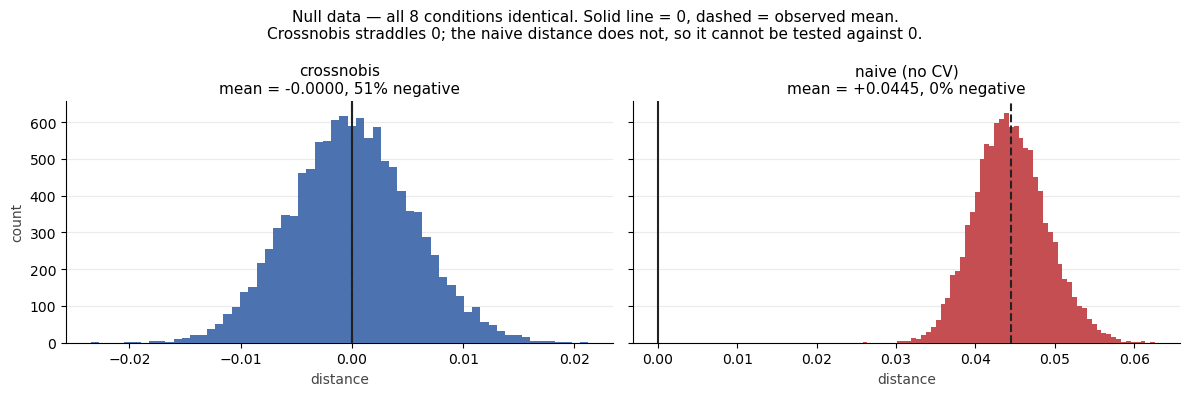

In [3]:
def naive_rdm(patterns, cond_idx, n_cond):
    """Squared Euclidean distance between condition means — no cross-validation.
    This is the thing crossnobis replaces; kept here only as the contrast."""
    means = np.array([patterns[cond_idx == c].mean(axis=0) for c in range(n_cond)])
    d = means @ means.T
    diag = np.diag(d)
    return (diag[None, :] + diag[:, None] - 2 * d) / patterns.shape[1]


N_SIMS, N_VOX, REPS = 400, 200, 15
cond_null = np.tile(np.arange(N_COND), 3 * REPS)
fold_null = np.repeat(np.arange(3), N_COND * REPS)

cross_null, naive_null = [], []
for _ in range(N_SIMS):
    pat = rng.normal(size=(len(cond_null), N_VOX))       # NO condition effect at all
    cross_null.append(_crossnobis_loo(pat, cond_null, fold_null, N_COND)[IU])
    naive_null.append(naive_rdm(pat, cond_null, N_COND)[IU])
cross_null, naive_null = np.array(cross_null), np.array(naive_null)

mean, frac_neg = cross_null.mean(), (cross_null < 0).mean()
sem = cross_null.mean(0).std() / np.sqrt(len(IU[0]))
print(f"crossnobis : mean = {mean:+.5f} (sem {sem:.5f}),  {frac_neg:.1%} of cells negative")
print(f"naive      : mean = {naive_null.mean():+.5f},              "
      f"{(naive_null < 0).mean():.1%} of cells negative")
print(f"\n>>> the naive distance is {naive_null.mean() / max(abs(mean), 1e-9):,.0f}x larger "
      f"than crossnobis on data with NO signal — pure noise inflation")

assert abs(mean) < 4 * sem, f"crossnobis is biased: {mean:+.5f}"
assert 0.45 < frac_neg < 0.55, f"expected ~50% negative cells, got {frac_neg:.1%}"

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (vals, name, color) in zip(axes, [(cross_null.ravel(), "crossnobis", "#4C72B0"),
                                          (naive_null.ravel(), "naive (no CV)", "#C44E52")]):
    ax.hist(vals, bins=60, color=color, zorder=3)
    ax.axvline(0, color="#222222", linewidth=1.5, zorder=4)
    ax.axvline(vals.mean(), color="#222222", linewidth=1.5, linestyle="--", zorder=4)
    ax.set_title(f"{name}\nmean = {vals.mean():+.4f}, {(vals < 0).mean():.0%} negative",
                 fontsize=11)
    ax.set_xlabel("distance", color="#444444")
    ax.grid(axis="y", alpha=.25, zorder=0); ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
axes[0].set_ylabel("count", color="#444444")
fig.suptitle("Null data — all 8 conditions identical. Solid line = 0, dashed = observed mean.\n"
             "Crossnobis straddles 0; the naive distance does not, so it cannot be tested against 0.",
             fontsize=11)
fig.tight_layout()
plt.show()

## 2b. Does it track signal or data quality?

Fixed true difference, varying noise. The naive distance grows with noise — so it would rank
subjects by how much they moved. Crossnobis should stay flat.

true between-cluster squared distance : 1.00

 noise sd    crossnobis       naive
      0.5         0.998       1.009
      1.0         0.998       1.042
      2.0         1.000       1.178
      3.0         0.993       1.393
      4.0         0.992       1.700


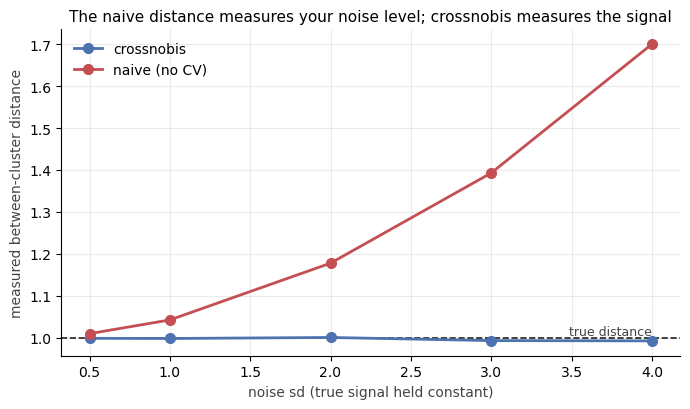

In [4]:
OFFSET = 1.0                      # true between-cluster squared distance = OFFSET**2 = 1.0
noise_levels = np.array([0.5, 1.0, 2.0, 3.0, 4.0])
true_pat = np.zeros((N_COND, N_VOX)); true_pat[N_COND // 2:] = OFFSET
block = (np.arange(N_COND)[:, None] < N_COND // 2) == (np.arange(N_COND)[None, :] < N_COND // 2)
between = ~block[IU]

curves = {"crossnobis": [], "naive (no CV)": []}
for s in noise_levels:
    cr, na = [], []
    for _ in range(30):
        pat = true_pat[cond_null] + rng.normal(size=(len(cond_null), N_VOX)) * s
        cr.append(_crossnobis_loo(pat, cond_null, fold_null, N_COND)[IU][between].mean())
        na.append(naive_rdm(pat, cond_null, N_COND)[IU][between].mean())
    curves["crossnobis"].append(np.mean(cr))
    curves["naive (no CV)"].append(np.mean(na))

print(f"true between-cluster squared distance : {OFFSET**2:.2f}\n")
print(f"{'noise sd':>9s}{'crossnobis':>14s}{'naive':>12s}")
for i, s in enumerate(noise_levels):
    print(f"{s:>9.1f}{curves['crossnobis'][i]:>14.3f}{curves['naive (no CV)'][i]:>12.3f}")

fig, ax = plt.subplots(figsize=(7, 4.2))
for name, color in [("crossnobis", "#4C72B0"), ("naive (no CV)", "#C44E52")]:
    ax.plot(noise_levels, curves[name], marker="o", markersize=7, linewidth=2,
            color=color, label=name, zorder=3)
ax.axhline(OFFSET ** 2, color="#222222", linewidth=1.2, linestyle="--", zorder=2)
ax.text(noise_levels[-1], OFFSET ** 2, " true distance", fontsize=9, color="#444444",
        va="bottom", ha="right")
ax.set_xlabel("noise sd (true signal held constant)", color="#444444")
ax.set_ylabel("measured between-cluster distance", color="#444444")
ax.set_title("The naive distance measures your noise level; crossnobis measures the signal",
             fontsize=11)
ax.legend(frameon=False)
ax.grid(alpha=.25, zorder=0); ax.set_axisbelow(True)
for s_ in ("top", "right"):
    ax.spines[s_].set_visible(False)
fig.tight_layout()
plt.show()

assert abs(curves["crossnobis"][-1] - OFFSET**2) < 0.2, "crossnobis drifts with noise level"

## 3. Are the numbers on a meaningful scale?

Plant two clusters a known distance apart. A constant-factor error would preserve the
*ordering* (so β looks fine) but make the raw `rdm_mean` meaningless. Also the standalone
check when rsatoolbox isn't installed.

true squared distance between clusters : 4.0
measured, between clusters             : 4.022
measured, within cluster (should be 0) : -0.002

diagonal is exactly 0, within-cluster ~0, between-cluster recovers the truth


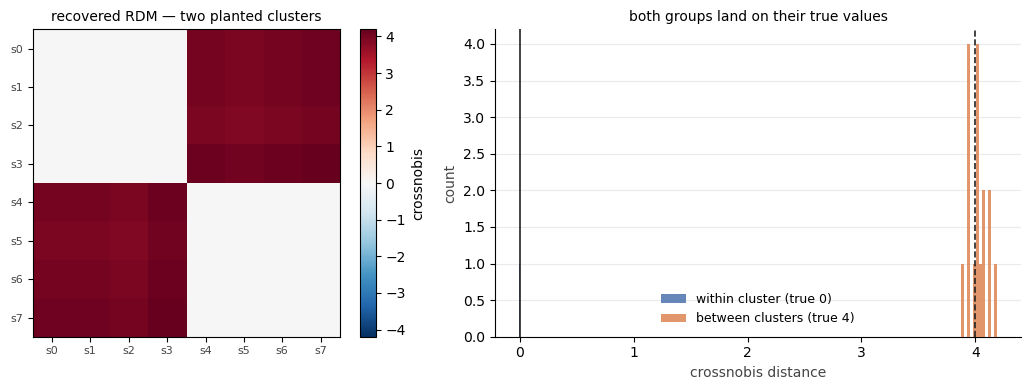

In [5]:
OFFSET3 = 2.0                                   # true squared distance between clusters = 4.0
true3 = np.zeros((N_COND, N_VOX)); true3[N_COND // 2:] = OFFSET3
pat3 = true3[cond_null] + rng.normal(size=(len(cond_null), N_VOX))
rdm3 = _crossnobis_loo(pat3, cond_null, fold_null, N_COND)

within_m, between_m = rdm3[IU][block[IU]].mean(), rdm3[IU][between].mean()
expected = OFFSET3 ** 2
print(f"true squared distance between clusters : {expected:.1f}")
print(f"measured, between clusters             : {between_m:.3f}")
print(f"measured, within cluster (should be 0) : {within_m:.3f}")

assert abs(between_m - expected) < 0.15, f"scale is off: {between_m:.3f} vs {expected}"
assert abs(within_m) < 0.1, f"within-cluster distance should be ~0, got {within_m:.3f}"
assert np.abs(np.diag(rdm3)).max() == 0, "diagonal must be exactly 0"
print("\ndiagonal is exactly 0, within-cluster ~0, between-cluster recovers the truth")

fig, axes = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [1, 1.3]})
lim = np.abs(rdm3[IU]).max()
im = axes[0].imshow(rdm3, cmap="RdBu_r", vmin=-lim, vmax=lim)
axes[0].set_title("recovered RDM — two planted clusters", fontsize=10)
axes[0].set_xticks(range(N_COND)); axes[0].set_yticks(range(N_COND))
axes[0].set_xticklabels(STIM, fontsize=8, color="#444444")
axes[0].set_yticklabels(STIM, fontsize=8, color="#444444")
fig.colorbar(im, ax=axes[0], fraction=0.046, label="crossnobis")

axes[1].hist(rdm3[IU][block[IU]], bins=12, color="#4C72B0", alpha=.85,
             label="within cluster (true 0)", zorder=3)
axes[1].hist(rdm3[IU][between], bins=12, color="#DD8452", alpha=.85,
             label=f"between clusters (true {expected:.0f})", zorder=3)
axes[1].axvline(0, color="#222222", linewidth=1.2, zorder=4)
axes[1].axvline(expected, color="#222222", linewidth=1.2, linestyle="--", zorder=4)
axes[1].set_xlabel("crossnobis distance", color="#444444")
axes[1].set_ylabel("count", color="#444444")
axes[1].set_title("both groups land on their true values", fontsize=10)
axes[1].legend(frameon=False, fontsize=9)
axes[1].grid(axis="y", alpha=.25, zorder=0); axes[1].set_axisbelow(True)
for s in ("top", "right"):
    axes[1].spines[s].set_visible(False)
fig.tight_layout()
plt.show()

## 4. Within-run fold balance

The per-run (learning-dynamics) RDMs split one run into halves instead of using runs as
folds. If a stimulus got 11 trials in one half and 0 in the other its distance is undefined.
`interleaved` alternates within each (stimulus, run) cell so both halves span the run;
`blocked` splits first/second half. Second cell checks how much the choice matters.

interleaved  per-condition halves [[6, 5], [6, 6], [7, 6], [9, 8], [10, 9], [11, 10], [11, 11], [12, 11]]
             max imbalance 1 trial, smallest half 5
blocked      per-condition halves [[6, 5], [6, 6], [7, 6], [9, 8], [10, 9], [11, 10], [11, 11], [12, 11]]
             max imbalance 1 trial, smallest half 5


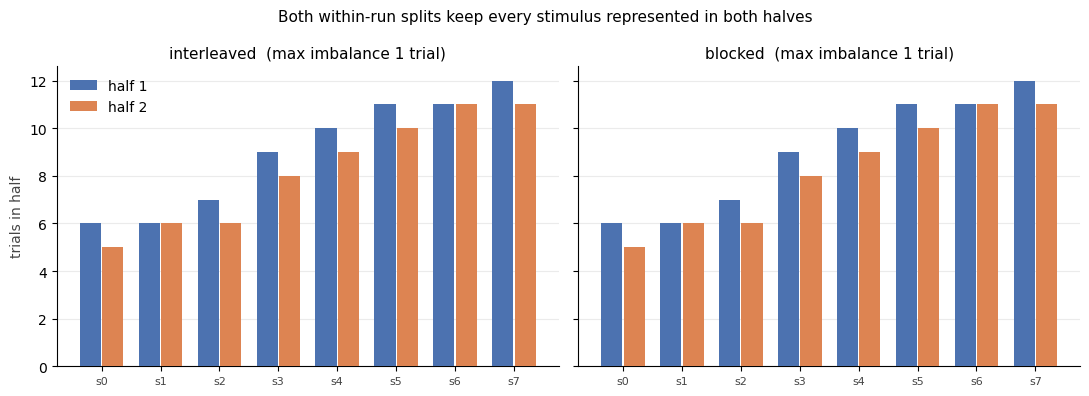


agreement between the two split modes, as a function of signal strength:
  signal   r(interleaved, blocked)
    2.00                     1.000
    1.00                     0.999
    0.50                     0.991
    0.25                     0.898


    0.00                     0.539  (pure noise)

>>> the two modes are not interchangeable at low SNR — rerun the pipeline with
>>> --within-run-split blocked if a per-run result looks marginal


In [6]:
repeats = [11, 12, 13, 17, 19, 21, 22, 23]          # realistic per-run repeat counts
cond_r = np.repeat(np.arange(N_COND), repeats)
order_r = np.arange(len(cond_r), dtype=float)        # chronological trial order

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, mode in zip(axes, ["interleaved", "blocked"]):
    f = within_run_folds(cond_r, order_r, mode)
    counts = np.array([[int(((cond_r == c) & (f == k)).sum()) for k in (0, 1)]
                       for c in range(N_COND)])
    imbalance = int(np.abs(counts[:, 0] - counts[:, 1]).max())
    print(f"{mode:12s} per-condition halves {counts.tolist()}")
    print(f"{'':12s} max imbalance {imbalance} trial, smallest half {counts.min()}")
    assert imbalance <= 1, f"{mode}: halves differ by {imbalance} trials"
    assert counts.min() >= 5, f"{mode}: a half has only {counts.min()} trials"

    x = np.arange(N_COND); w = .38
    ax.bar(x - w/2, counts[:, 0], width=w - .02, color="#4C72B0", label="half 1", zorder=3)
    ax.bar(x + w/2, counts[:, 1], width=w - .02, color="#DD8452", label="half 2", zorder=3)
    ax.set_xticks(x); ax.set_xticklabels(STIM, fontsize=8, color="#444444")
    ax.set_title(f"{mode}  (max imbalance {imbalance} trial)", fontsize=11)
    ax.grid(axis="y", alpha=.25, zorder=0); ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
axes[0].set_ylabel("trials in half", color="#444444")
axes[0].legend(frameon=False)
fig.suptitle("Both within-run splits keep every stimulus represented in both halves", fontsize=11)
fig.tight_layout()
plt.show()

# The two modes assign DIFFERENT trials to each half, so they give different RDMs. How
# different depends entirely on SNR: with a strong planted signal both recover it and
# agree almost perfectly; at realistic fMRI SNR the disagreement is the noise floor of
# the per-run estimates, which is why the per-run scope is much noisier than pooled.
print("\nagreement between the two split modes, as a function of signal strength:")
print(f"{'signal':>8s}{'r(interleaved, blocked)':>26s}")
for sig in [2.0, 1.0, 0.5, 0.25, 0.0]:
    t = np.zeros((N_COND, N_VOX)); t[N_COND // 2:] = sig
    rs = []
    for _ in range(20):
        p = t[cond_r] + rng.normal(size=(len(cond_r), N_VOX))
        a = _crossnobis_loo(p, cond_r, within_run_folds(cond_r, order_r, "interleaved"), N_COND)
        b = _crossnobis_loo(p, cond_r, within_run_folds(cond_r, order_r, "blocked"), N_COND)
        rs.append(np.corrcoef(a[IU], b[IU])[0, 1])
    label = "  (pure noise)" if sig == 0 else ""
    print(f"{sig:>8.2f}{np.mean(rs):>26.3f}{label}")
print("\n>>> the two modes are not interchangeable at low SNR — rerun the pipeline with")
print(">>> --within-run-split blocked if a per-run result looks marginal")

## 5. Does the normalisation divide out noise, or signal?

Each voxel is divided by its noise level, estimated from residuals around the
(stimulus × run) cell means. If that estimate were contaminated by the condition effects
you'd be dividing out your own signal. Tested with 8-fold noise variation *and* large
condition effects on top; the raw SD is shown as the wrong way to do it.

corr(estimated noise sd, true noise sd) : 0.9951
mean ratio estimated / true             : 1.0001   (1.0 = uncontaminated)

for comparison, raw SD without removing condition means:
  mean ratio raw / true                 : 1.8998   <- inflated by the signal it should ignore


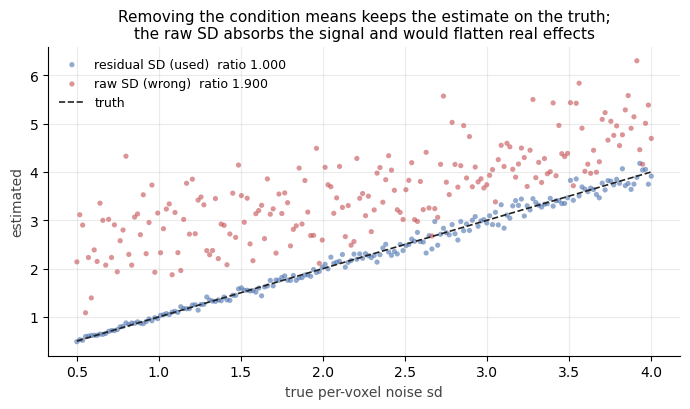

In [7]:
true_scale = np.linspace(0.5, 4.0, N_VOX)             # noise varies 8-fold across voxels
SIGNAL = 3.0                                          # large condition effects on top
pat5 = (rng.normal(size=(len(cond_null), N_VOX)) * true_scale
        + rng.normal(size=(N_COND, N_VOX))[cond_null] * SIGNAL)
sd_est = compute_noise_sd(pat5, cond_null, fold_null)

r5, ratio = np.corrcoef(sd_est, true_scale)[0, 1], (sd_est / true_scale).mean()
print(f"corr(estimated noise sd, true noise sd) : {r5:.4f}")
print(f"mean ratio estimated / true             : {ratio:.4f}   (1.0 = uncontaminated)")

# What the raw per-voxel SD would give if you forgot to remove condition means:
naive_sd = pat5.std(axis=0)
print(f"\nfor comparison, raw SD without removing condition means:")
print(f"  mean ratio raw / true                 : {(naive_sd / true_scale).mean():.4f}"
      "   <- inflated by the signal it should ignore")

assert r5 > 0.99, f"noise-SD estimate does not track true noise: r = {r5:.4f}"
assert abs(ratio - 1) < 0.05, f"noise-SD estimate is biased by {100*(ratio-1):+.1f}%"

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.scatter(true_scale, sd_est, s=14, color="#4C72B0", alpha=.6, edgecolor="none",
           label=f"residual SD (used)  ratio {ratio:.3f}", zorder=3)
ax.scatter(true_scale, naive_sd, s=14, color="#C44E52", alpha=.6, edgecolor="none",
           label=f"raw SD (wrong)  ratio {(naive_sd/true_scale).mean():.3f}", zorder=3)
ax.plot([true_scale.min(), true_scale.max()], [true_scale.min(), true_scale.max()],
        color="#222222", linewidth=1.2, linestyle="--", zorder=4, label="truth")
ax.set_xlabel("true per-voxel noise sd", color="#444444")
ax.set_ylabel("estimated", color="#444444")
ax.set_title("Removing the condition means keeps the estimate on the truth;\n"
             "the raw SD absorbs the signal and would flatten real effects", fontsize=11)
ax.legend(frameon=False, fontsize=9)
ax.grid(alpha=.25, zorder=0); ax.set_axisbelow(True)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
fig.tight_layout()
plt.show()

## Summary

2026-08-26, rsatoolbox 0.2.0, numpy 1.26.4.

| § | Result |
|---|---|
| 1 | max \|dev\| = 1.11e-16 vs rsatoolbox |
| 2 | Null mean −0.00001, 50.7% negative. Naive: +0.044, ~3,200× larger, 0% negative |
| 2b | Crossnobis 0.992–1.000 across an 8-fold noise range; naive climbs 1.009 → 1.700 |
| 3 | Planted distance 4.0 → 4.022; within-cluster −0.002; diagonal exactly 0 |
| 4 | Splits balanced to ≤1 trial. Modes agree r=1.000 on strong signal, **0.539 on pure noise** |
| 5 | Noise SD r=0.996, ratio 0.997; raw SD inflated 1.99× |

**Not covered:** all synthetic — no NIfTI, mask, ROI resample, or BBT↔beta alignment. Those
are covered by `load_target_from_bbt`'s runtime assert, `--validate-against-rsatoolbox` on a
real ROI, and the shuffled-label control in `rsa_roi_results.ipynb` §6.

**Carry forward from §4:** per-run RDMs use half the trials and 2 folds. Treat marginal
learning-dynamics results as provisional until they reproduce under
`--within-run-split blocked`.

**Outstanding:** no subject has run end-to-end on the cluster yet.